# Customer Churn Analysis using Python & SQL

## Objective

Analyze customer churn by integrating data from multiple relational tables, performing data cleaning, feature engineering, exploratory data analysis (EDA), and visualizing key business insights using Python.

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1. Import database / data  

In [2]:
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
# PRAGMA is a special command in SQLite used to:
# inspect db information, control db settings, retrieve metadata about tables

In [5]:
# df_db_support

## 2. Data cleaning

In [6]:
# df_db_customer.head() # customer table
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
96,0040-QPCQP,neha,India,Rajasthan,Women,1998-01-05 00:00:00,None,None
97,0075-HBBLM,kavya,India,West Bengal,Male,2002-03-23 00:00:00,sports,None
98,0042-CHJPG,bhavna,India,Meghalaya,Men,2002-05-07 00:00:00,sports,None
99,0051-PBHPV,pradeep,Nepal,Kathmandu,Men,1970-05-14 00:00:00,movie,None
100,0074-JZOJD,pooja,Nepal,Pokhara,Men,1971-10-22 00:00:00,travel,None


In [7]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  101 non-null    object
 1   name        101 non-null    object
 2   country     91 non-null     object
 3   state       101 non-null    object
 4   gender      101 non-null    object
 5   dob         101 non-null    object
 6   interests   60 non-null     object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 6.4+ KB


In [8]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

#### a. Rename Col

In [9]:
# a. rename col - name to customer_name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

#### b. Drop columns

In [10]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)

df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)  # using col name

In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     101 non-null    object
 1   customer_name  101 non-null    object
 2   country        91 non-null     object
 3   state          101 non-null    object
 4   gender         101 non-null    object
 5   dob            101 non-null    object
dtypes: object(6)
memory usage: 4.9+ KB


#### c. Change data type

In [12]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

#### d. Data standardization

In [13]:
# d. data standardization - gender

# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [14]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

#### e. Fix missing values

In [15]:
# e. fix missing values - country

# df_db_customer['country'].isna().sum()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01
43,0077-NTUXM,riya,None,Bihar,Male,1987-06-12
51,0080-IZGWC,ishaan,None,Kerala,Male,1995-11-19
55,0065-RWISH,girish,None,Karnataka,Male,1984-02-10
62,0044-BYZHZ,sanjay,None,Tamil Nadu,Male,1978-12-08
83,0045-SBJSZ,kiran,None,Gujarat,Female,1993-12-15
91,0033-RKNTE,vihaan,None,Rajasthan,Male,1975-08-31
92,0097-DJIHY,vihaan,None,Meghalaya,Male,1987-05-12


In [16]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [17]:
df_db_customer[df_db_customer['country'].isna()] # no null value in country col

,customerid,customer_name,country,state,gender,dob


In [18]:
df_db_subscription.head() # subcription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [19]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               101 non-null    object 
 1   subscription_start_date  101 non-null    object 
 2   subscription_type        101 non-null    object 
 3   renewal_date             101 non-null    object 
 4   plan_type                101 non-null    object 
 5   contract_type            101 non-null    object 
 6   cancellation_date        37 non-null     object 
 7   cancellation_reason      37 non-null     object 
 8   monthly_charges          101 non-null    float64
 9   cltv                     101 non-null    int64  
 10  churn_score              101 non-null    int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 8.8+ KB


In [20]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               101 non-null    object        
 1   subscription_start_date  101 non-null    datetime64[ns]
 2   subscription_type        101 non-null    object        
 3   renewal_date             101 non-null    datetime64[ns]
 4   plan_type                101 non-null    object        
 5   contract_type            101 non-null    object        
 6   cancellation_date        37 non-null     datetime64[ns]
 7   cancellation_reason      37 non-null     object        
 8   monthly_charges          101 non-null    float64       
 9   cltv                     101 non-null    int64         
 10  churn_score              101 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 8.8+ KB


In [21]:
df_db_support.head() # support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [22]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      47 non-null     object
 1   complaint_date  47 non-null     object
 2   escalations     47 non-null     object
 3   csat_score      47 non-null     int64 
 4   col_1           0 non-null      object
 5   comment         23 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.3+ KB


In [23]:
# drop columns
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [24]:
# change data type to date - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      47 non-null     object        
 1   complaint_date  47 non-null     datetime64[ns]
 2   escalations     47 non-null     object        
 3   csat_score      47 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.6+ KB


## 3. Feature Engineering & Data Analysis

#### Create a new col

In [25]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


#### Merge Dataframes - JOINs

In [26]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [27]:
df_db_subscription.shape

(101, 12)

In [28]:
df.shape

(112, 20)

In [29]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 101
df_db_customer unique value: 101
df_db_support unique value: 36
df_db_support all value: 47


In [30]:
# df_db_support

In [31]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [32]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [33]:
df_db_support['customerid'].size

36

In [34]:
# merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [35]:
df.shape

(101, 21)

#### Export dataframe

In [36]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

## Data Analysis

In [37]:
# 1. Churn Rate

In [38]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  36.63 %


In [39]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  63.37 %


In [40]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           37.04
1   Premium           45.45
2  Standard           29.27


In [41]:
# 4 a. Churn by state + sum(revenue) & count of users  
# 4 b. Churn by subscription type + sum(revenue) & count of users   


#  Churn, Revenue, and Users by State ---
print("--- Analysis by State ---")
churn_by_state = df.groupby('state').agg(
    total_users=('customerid', 'count'),
    churned_users=('churn_flag', 'sum'),
    total_monthly_revenue=('monthly_charges', 'sum')
).reset_index()

# Calculate Churn Rate per State
churn_by_state['churn_rate_pct'] = (churn_by_state['churned_users'] / churn_by_state['total_users'] * 100).round(2)
print(churn_by_state)


#  Churn, Revenue, and Users by Subscription Type ---
print("\n--- Analysis by Subscription Type ---")
churn_by_sub_type = df.groupby('subscription_type').agg(
    total_users=('customerid', 'count'),
    churned_users=('churn_flag', 'sum'),
    total_monthly_revenue=('monthly_charges', 'sum')
).reset_index()

# Calculate Churn Rate per Subscription Type
churn_by_sub_type['churn_rate_pct'] = (churn_by_sub_type['churned_users'] / churn_by_sub_type['total_users'] * 100).round(2)
print(churn_by_sub_type)



--- Analysis by State ---
            state  total_users  churned_users  total_monthly_revenue  \
0           Assam            6              0                  99.77   
1           Bihar            3              0                  44.72   
2           Delhi            5              1                  60.55   
3         Gujarat            3              1                  45.74   
4       Karnataka            7              4                 106.19   
5       Kathmandu            8              3                 110.98   
6          Kerala            4              1                  50.29   
7     Maharashtra            8              2                 114.34   
8       Meghalaya            8              3                 107.78   
9        Nagaland            6              3                 112.11   
10        Pokhara            5              2                  73.06   
11         Punjab            2              1                  41.19   
12      Rajasthan            5        

In [42]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  16.82


In [43]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1285 0


In [44]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 606.62


In [45]:
# 8. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  15.84 %


In [46]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.47


In [47]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.23


In [48]:
# 11. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

In [71]:
cltv_loss = df.loc[df['churn_flag'] == 1, 'cltv'].sum()
print("CLTV Loss =", cltv_loss)

CLTV Loss = 9748


## 4. Visualization using Matplotlib

In [72]:
# best practice to create a copy then work on it
df_visual = df.copy()

In [73]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

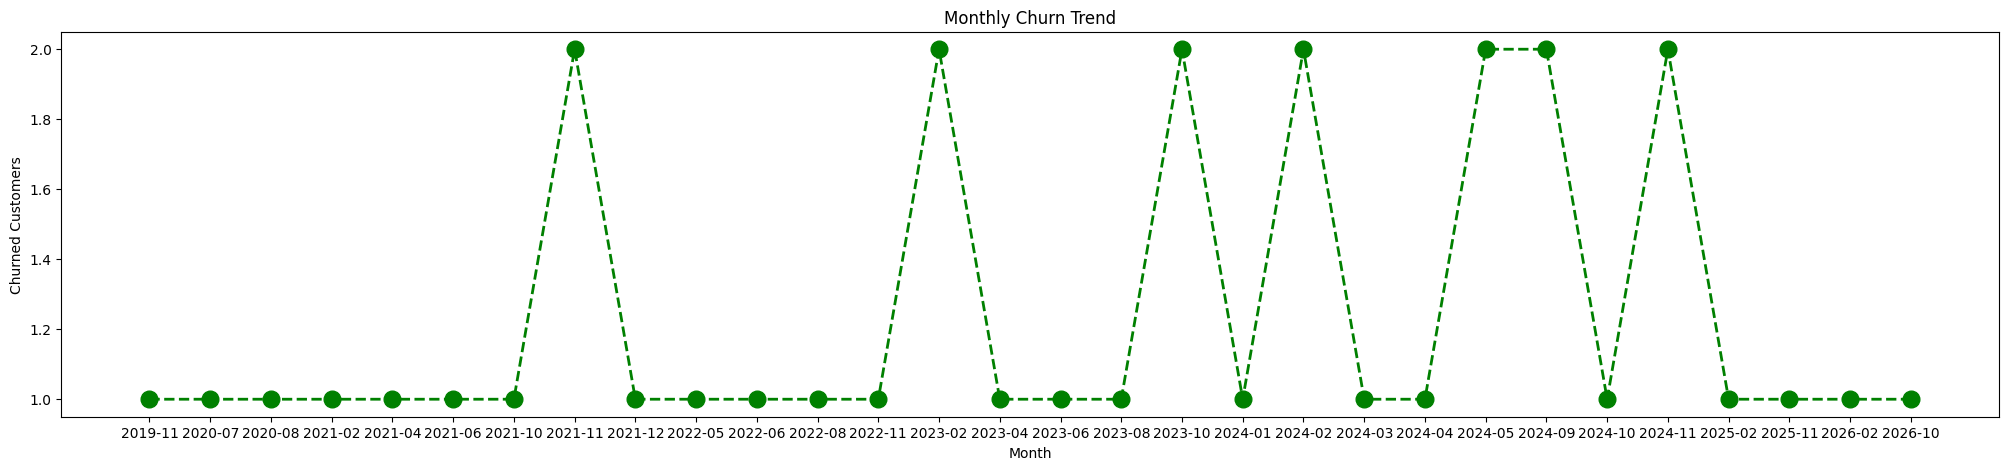

In [74]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(25,5))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

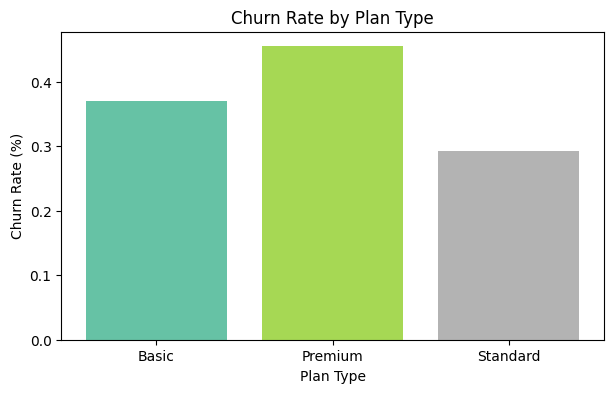

In [75]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

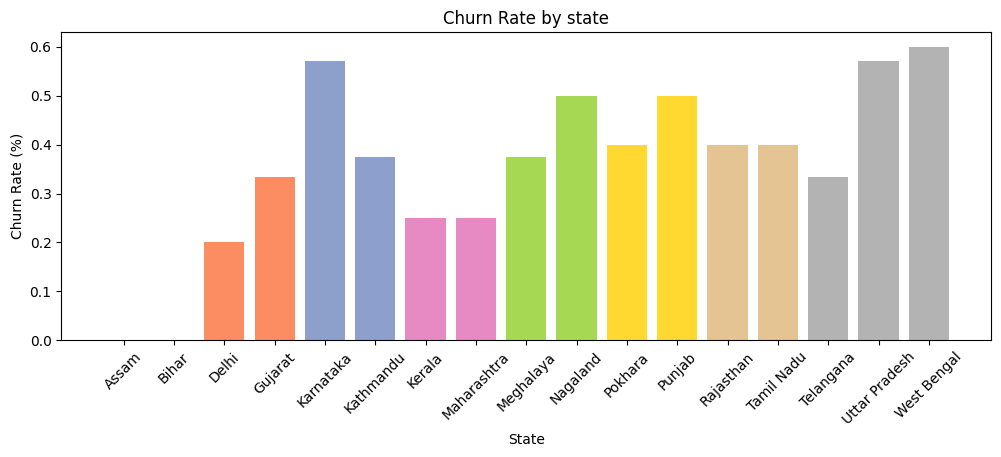

In [76]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by state')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

## Visulaization using Seaborn

In [77]:
# Heatmap (Correlation Matrix)

In [78]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [79]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [80]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [81]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

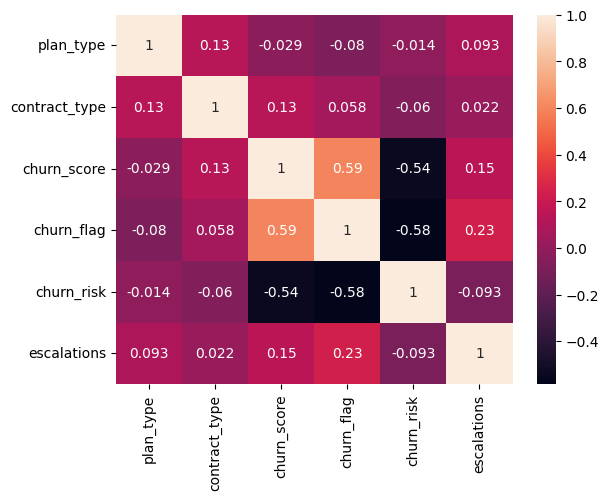

In [82]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [83]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : ['Standard' 'Premium' 'Basic']
contract_type : ['Annual' 'Monthly']
churn_risk : ['low' 'high' 'med']


In [84]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [85]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [86]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

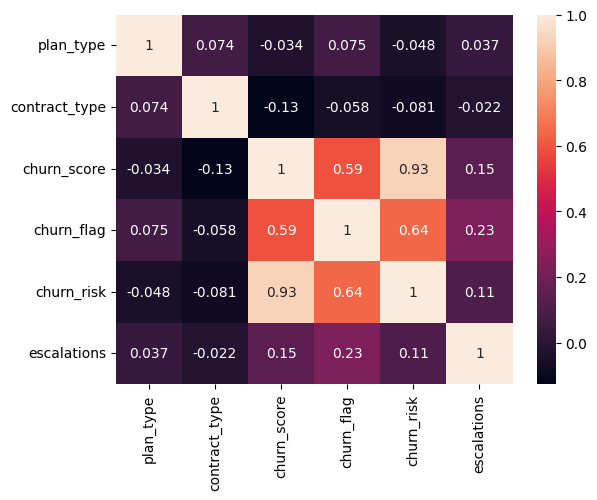

In [87]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

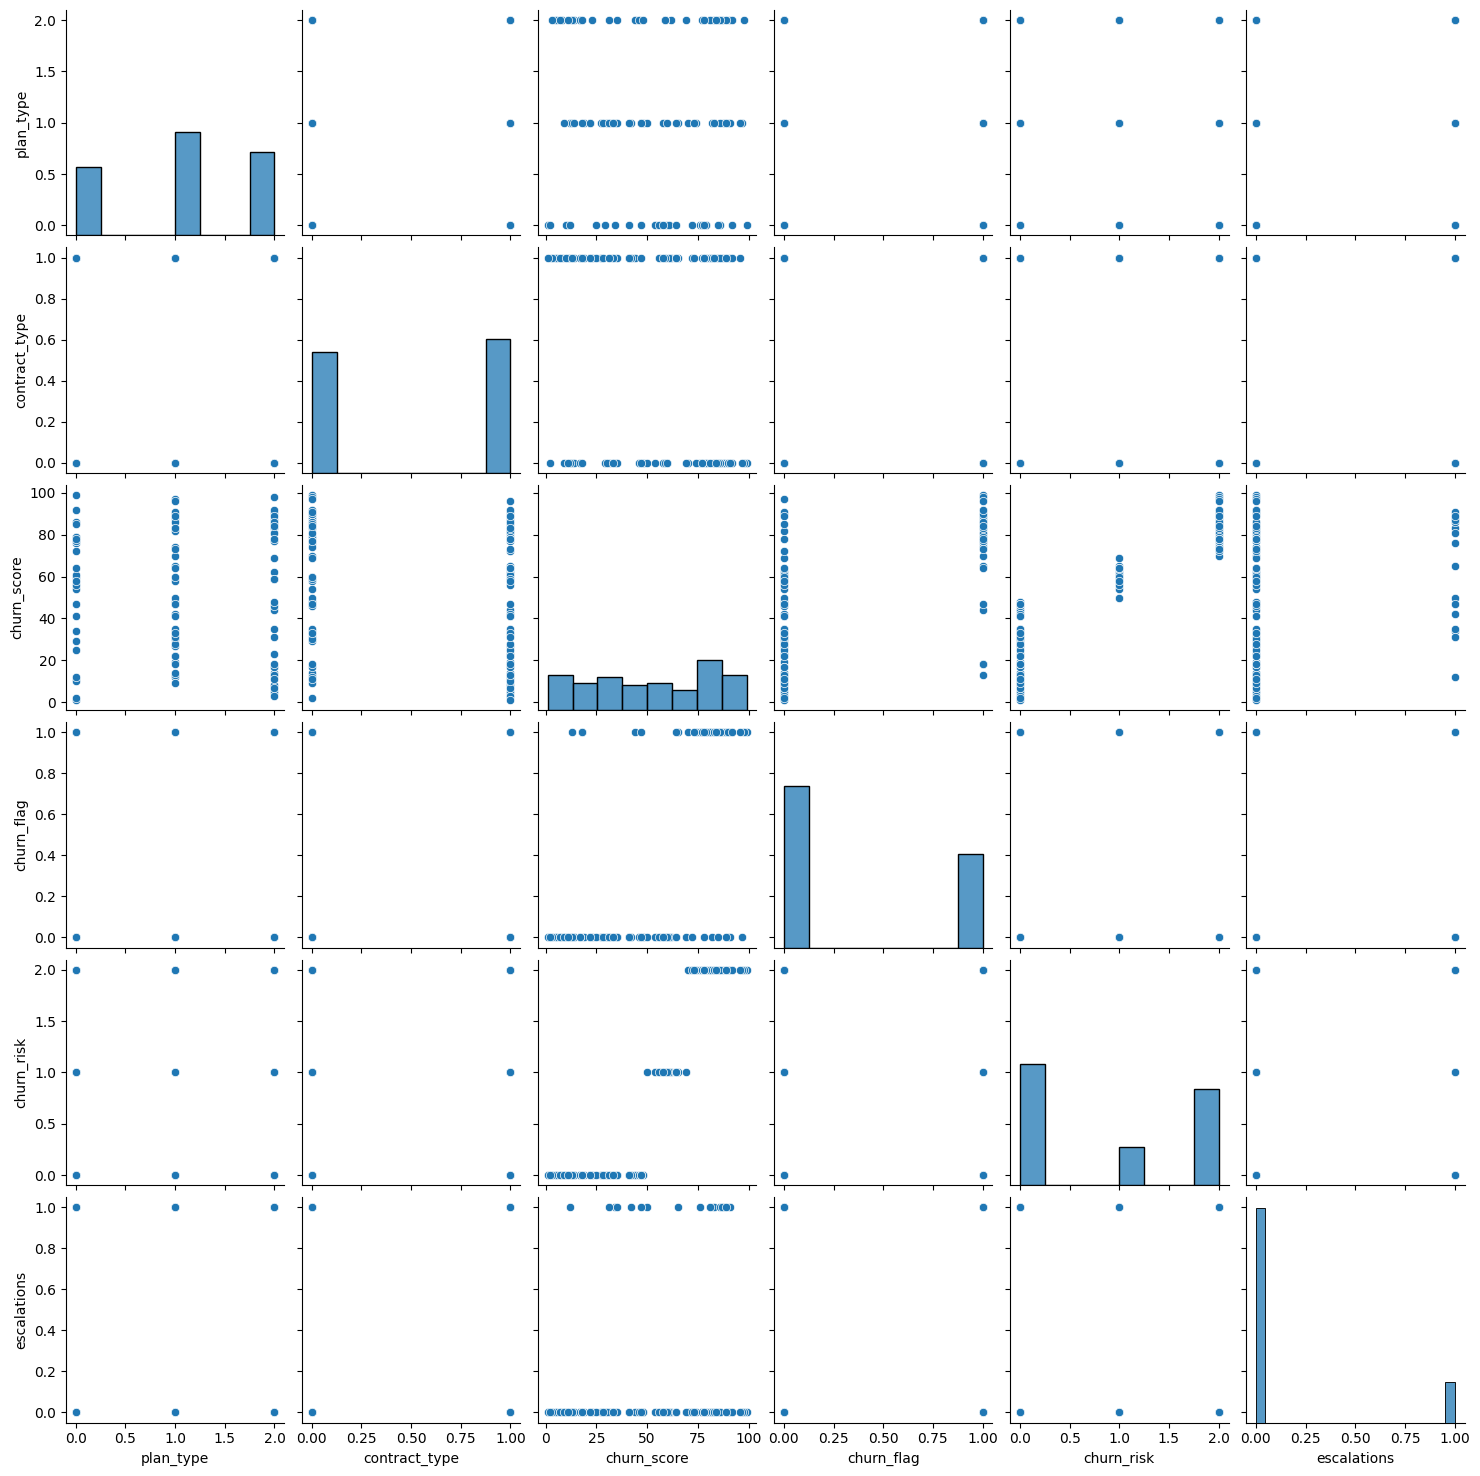

In [88]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

In [89]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

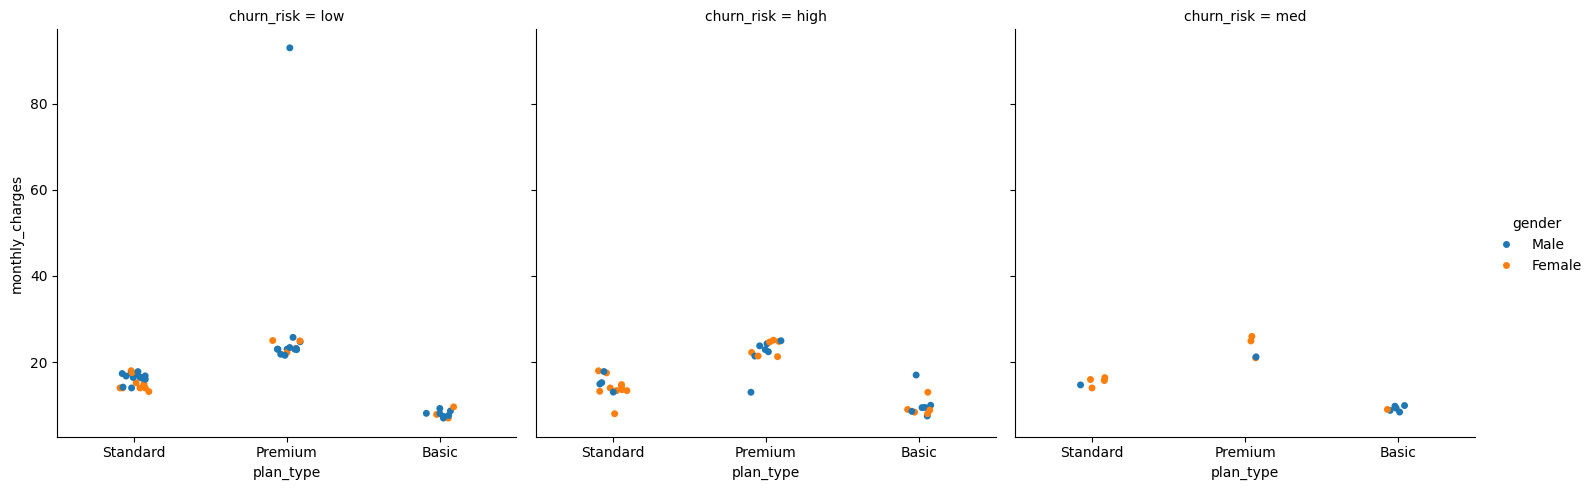

In [90]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

## Pivot table

In [91]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.370370
Premium,0.454545
Standard,0.292683


In [92]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.370370,27,244.45
Premium,0.454545,33,828.68
Standard,0.292683,41,625.36


## Project Completed :)

In [93]:
# Project Completed Here.

## Business Insights

- Overall Churn Rate: **36.63%**
- Retention Rate: **63.37%**
- Premium plan customers show the highest churn rate.
- Karnataka records the highest customer churn.
- Total Revenue at Risk due to churn: **₹606.62**
- Estimated CLTV Loss: **₹9,748**
- Customers with more complaints and escalations are significantly more likely to churn.
- High-risk customers contribute the majority of expected revenue loss.

## Recommendations

- Prioritize retention campaigns for Premium plan customers.
- Encourage Monthly subscribers to switch to Annual plans through discounts and loyalty offers.
- Improve customer support response time to reduce complaint-driven churn.
- Investigate the reasons behind high churn in Karnataka and implement targeted retention strategies.
- Monitor high-risk customers proactively using churn prediction scores.